In [ ]:
import pandas as pd
import numpy as np

## **Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto**

In [ ]:
#Carga de dataframe
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12


In [ ]:
import pandas as pd
import numpy as np

# Copia del dataframe
df_clean = df.copy()

# 1. Revisar datos faltantes
print(df_clean.isnull().sum())

# 2. Convertir tipos de datos
# Convertir la columna de fechas a tipo datetime
df_clean['FechaIngreso'] = pd.to_datetime(df_clean['FechaIngreso'], errors='coerce')
# Y con errors='coerce' se convierten los valores inválidos o None en NaT

# 3. Manejo de valores inválidos
# Se elimina el valor negativo y se reemplaza por NaN
df_clean.loc[df_clean['Edad'] < 0, 'Edad'] = np.nan

# 4. Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# 5. Imputación de datos

# 5.1 Edad
# Se imputa con la mediana
df_clean['Edad'] = df_clean['Edad'].fillna(df_clean['Edad'].median())

# 5.2 Ingreso
# Se imputar con la media
df_clean['Ingreso'] = df_clean['Ingreso'].fillna(df_clean['Ingreso'].mean())

# 5.3 Ciudad
# Se imputa con la moda
df_clean['Ciudad'] = df_clean['Ciudad'].fillna(df_clean['Ciudad'].mode()[0])

# 5.4 Nombre
# Se deja como "Desconocido"
df_clean['Nombre'] = df_clean['Nombre'].fillna('Desconocido')


# 6. Verificación final
print(df_clean)

Nombre          1
Edad            2
Ciudad          1
Ingreso         2
FechaIngreso    2
dtype: int64
        Nombre  Edad    Ciudad  Ingreso FechaIngreso
0          Ana  25.0    Bogotá   3500.0   2023-01-01
1         Luis  27.0  Medellín   4800.0   2023-01-05
2        Pedro  35.0    Bogotá   4660.0          NaT
3  Desconocido  29.0  Medellín   5200.0   2023-01-10
4        Marta  27.0      Cali   5100.0   2023-01-12
5         Luis  25.0    Bogotá   4660.0          NaT
6        Sofía  27.0      Cali   4700.0   2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>


In [ ]:
df2 = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})
df2.head()

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15


In [ ]:
# Copia del dataframe
df2_clean = df2.copy()

#1
total_registros = len(df2)
print("1. Total de registros originales:", total_registros)
print("")

#2
duplicados_exactos = df2[df2.duplicated()]
print("2.1. Duplicados exactos:\n", duplicados_exactos)
print("")
print("2.2. Cantidad duplicados exactos:", duplicados_exactos.shape[0])
print("")

#3
duplicados_parciales = df2_clean[df2.duplicated(subset=['ID', 'Nombre', 'Ciudad'])]
print("3.1. Duplicados por columnas:\n", duplicados_parciales)
print("")
print("3.2. Cantidad duplicados por columnas:", duplicados_parciales.shape[0])
print("")

#4. Se eliminan los parciales porque para la lógica de nuestro negocio un ID repetido no es funcional
a_eliminar = duplicados_parciales.shape[0]
print("4. Registros a eliminar:", a_eliminar)
print("")

#5.
df_limpio = df2.drop_duplicates(subset=['ID', 'Nombre', 'Ciudad'])
print("5. Registros después de limpieza:", len(df_limpio))
print("")
print(df_limpio)

1. Total de registros originales: 7

2.1. Duplicados exactos:
     ID  Nombre  Edad Ciudad FechaRegistro
2  102    Luis    30   Cali    2023-01-05
5  104  Carlos    40   Cali    2023-01-15

2.2. Cantidad duplicados exactos: 2

3.1. Duplicados por columnas:
     ID  Nombre  Edad Ciudad FechaRegistro
2  102    Luis    30   Cali    2023-01-05
5  104  Carlos    40   Cali    2023-01-15
6  104  Carlos    41   Cali    2023-01-16

3.2. Cantidad duplicados por columnas: 3

4. Registros a eliminar: 3

5. Registros después de limpieza: 4

    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15


## **Ejercicio 3. Corrección de errores tipográficos o de codificación**

In [ ]:
df3 = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})
df3.head()

,Ciudad
0,bogota
1,Bogotá
2,BOGOTA
3,bogotá
4,bogata


In [ ]:
import pandas as pd
import unicodedata

# Función para estandarizar texto
def estandarizar_ciudad(texto):
    if pd.isna(texto):
        return texto

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar tildes y caracteres especiales
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # Corrección manual de errores
    correcciones = {
        'bogata': 'bogota',
        'bogota': 'bogota',
        'cali': 'cali',
        'medellin': 'medellin'
    }

    return correcciones.get(texto, texto)

# Aplicar limpieza
df3['Ciudad_Estandarizada'] = df3['Ciudad'].apply(estandarizar_ciudad)
# Mostrar resultado
print(df3)

      Ciudad Ciudad_Estandarizada
0     bogota               bogota
1     Bogotá               bogota
2     BOGOTA               bogota
3     bogotá               bogota
4     bogata               bogota
5     Bógota               bogota
6     BogoTa               bogota
7       Cali                 cali
8       calí                 cali
9   medellín             medellin
10  medellin             medellin


##**Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)**

* **Escenario 1: MCAR**
Los datos faltantes no dependen de ninguna variable, ocurren completamente al azar.
* **Escenario 2: MAR**
La ausencia de datos en horas de estudio depende del promedio académico (otra variable observable).
* **Escenario 3: MAR**
Pasa lo mismo: los valores faltantes están relacionados con el promedio, no son aleatorios.
* **Escenario 4: MAR**
Los datos faltantes en promedio dependen del género, que es una variable observada.
* **Escenario 5: MNAR**
Los estudiantes no reportan las horas porque el valor es bajo, es decir, depende del mismo dato faltante.

##**Ejercicio 5. Imputación con KNN y regresión**

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df5 = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Valores faltantes
df5.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df5.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df5.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

###**¿Qué variables tienen más datos faltantes?**

In [31]:
df5.isnull().sum()
df5.isnull().mean()*100

,0
Edad,0.000000
Promedio,13.333333
Horas_estudio,13.333333
Ingreso_familiar,10.000000
Semestres_cursados,0.000000


Las variables con mayor proporción de datos faltantes son Promedio y Horas_estudio.

###**¿Hay patrón o son aleatorios?**

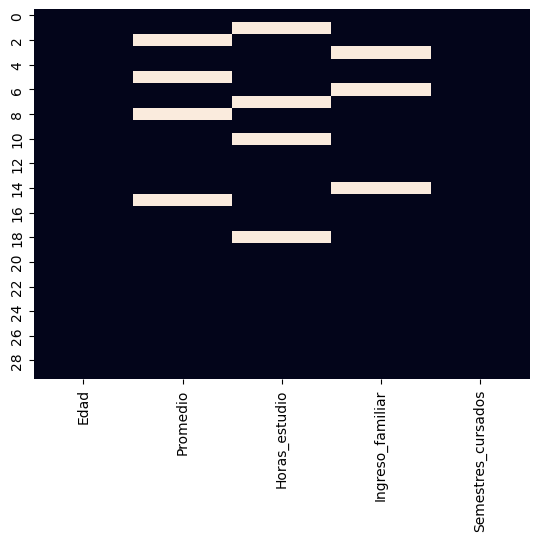

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df5.isnull(), cbar=False)
plt.show()


Los datos parecen aleatorios **(MCAR)**, aunque no se puede asegurar totalmente sin análisis estadístico más profundo.

###**Imputación con KNN**

In [33]:
from sklearn.impute import KNNImputer

imputer_knn = KNNImputer(n_neighbors=3)

df5_knn = pd.DataFrame(
    imputer_knn.fit_transform(df5),
    columns=df5.columns
)

###**Imputación con regresión**

In [36]:
from sklearn.linear_model import LinearRegression

df5_reg = df5.copy()

for col in df5.columns:
    if df5_reg[col].isnull().sum() > 0:

        train = df5_reg[df5_reg[col].notna()]
        test = df5_reg[df5_reg[col].isna()]

        X_train = train.drop(columns=[col])
        y_train = train[col]

        X_test = test.drop(columns=[col])

        X_train = X_train.fillna(X_train.mean())
        X_test = X_test.fillna(X_train.mean())

        model = LinearRegression()
        model.fit(X_train, y_train)

        df5_reg.loc[df5_reg[col].isna(), col] = model.predict(X_test)

###**Análisis:**

####**Estadísticas**

In [37]:
df5.describe()
df5_knn.describe()
df5_reg.describe()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,39.866667,3.375329,18.680709,4.331510e+06,5.533333
std,11.512312,0.837400,9.726256,1.660239e+06,2.596195
min,19.000000,2.040000,0.000000,1.291234e+06,1.000000
25%,32.250000,2.692500,13.011533,2.949214e+06,4.000000
50%,40.500000,3.315000,20.423747,4.361860e+06,6.000000
75%,46.750000,3.987500,24.000000,5.264558e+06,7.000000
max,59.000000,4.950000,35.000000,7.930144e+06,9.000000


####**Histogramas**

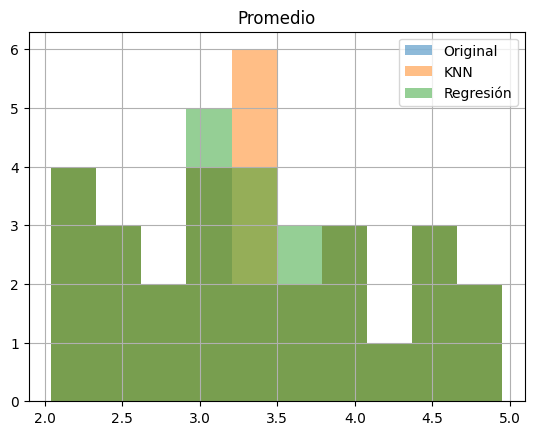

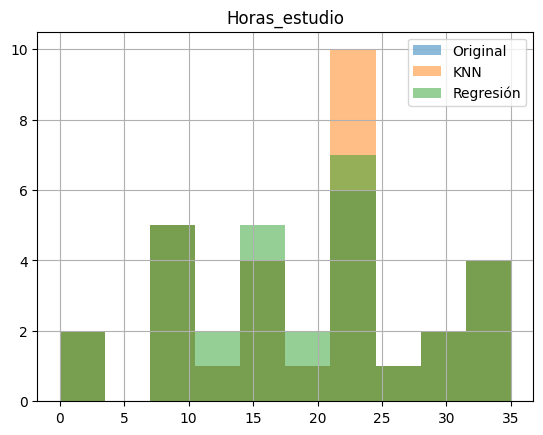

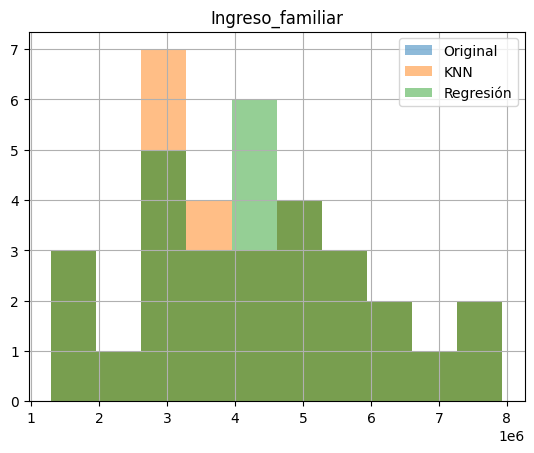

In [38]:
import matplotlib.pyplot as plt

cols = ['Promedio', 'Horas_estudio', 'Ingreso_familiar']

for col in cols:
    plt.figure()
    df5[col].hist(alpha=0.5, label='Original')
    df5_knn[col].hist(alpha=0.5, label='KNN')
    df5_reg[col].hist(alpha=0.5, label='Regresión')
    plt.legend()
    plt.title(col)
    plt.show()

####**Correlación**

In [39]:
df5.corr()
df5_knn.corr()
df5_reg.corr()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
Edad,1.000000,0.106976,0.128070,-0.098509,-0.086376
Promedio,0.106976,1.000000,-0.029575,0.093140,0.005953
Horas_estudio,0.128070,-0.029575,1.000000,-0.267313,-0.123371
Ingreso_familiar,-0.098509,0.093140,-0.267313,1.000000,0.171257
Semestres_cursados,-0.086376,0.005953,-0.123371,0.171257,1.000000




**KNN**
* Mantiene mejor la distribución original.
* Valores imputados son similares a vecinos reales.
* Más realista para datos como horas o ingresos.

**Regresión:**
* Genera valores más suavizados.
* Puede perder variabilidad (datos muy “perfectos”).
* Existe riesgo de introducir sesgo si la relación entre variables no es completamente lineal.


**KNN** preserva mejor la estructura y variabilidad de los datos al basarse en observaciones similares.
La regresión tiende a suavizar los valores imputados, lo que puede disminuir la dispersión y alterar ligeramente la distribución original.



##**Ejercicio 6. Imputación con LOCF y NOCB**

In [12]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df6= pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Valores faltantes
df6.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df6.loc[[7, 8, 20], 'Inventario'] = np.nan
df6.loc[[1, 2, 18, 19], 'Clientes'] = np.nan

df6 = df6.sort_values('Fecha').reset_index(drop=True)

In [24]:
mask = df6.isnull()
df6

,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
9,2023-01-10,383.23,23.0,48.0


###**Qué variables tienen datos faltantes consecutivos?**

* **Ventas:** sí (índices 3, 4, 5 y 12, 13 → bloques consecutivos)
* **Inventario:** sí (7, 8)
* **Clientes:** sí (1, 2 y 18, 19)



### **Por qué es relevante en series temporales?**

Porque los datos tienen dependencia temporal, es decir, los valores cercanos en el tiempo suelen estar relacionados, por lo que los faltantes consecutivos pueden afectar la continuidad y tendencias.

### **Implicaciones del orden de los datos**

El orden es fundamental porque los métodos como LOCF y NOCB dependen de la secuencia temporal; si los datos no están ordenados, la imputación sería incorrecta.

###**Imputación con LOCF**

In [16]:
df6_locf = df6.copy()
df6_locf[['Ventas','Inventario','Clientes']] = df6_locf[['Ventas','Inventario','Clientes']].fillna(method='ffill')

/tmp/ipykernel_5934/2784717145.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df6_locf[['Ventas','Inventario','Clientes']] = df6_locf[['Ventas','Inventario','Clientes']].fillna(method='ffill')


###**Imputación con NOCB**

In [17]:
df6_nocb = df6.copy()
df6_nocb[['Ventas','Inventario','Clientes']] = df6_nocb[['Ventas','Inventario','Clientes']].fillna(method='bfill')

/tmp/ipykernel_5934/4095273984.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df6_nocb[['Ventas','Inventario','Clientes']] = df6_nocb[['Ventas','Inventario','Clientes']].fillna(method='bfill')


###**COMPARACIÓN**

In [19]:
comparacion = pd.DataFrame({
    'Original': df6['Ventas'],
    'LOCF': df6_locf['Ventas'],
    'NOCB': df6_nocb['Ventas']
})

comparacion[comparacion['Original'].isna()]

,Original,LOCF,NOCB
3,NaN,392.80,123.23
4,NaN,392.80,123.23
5,NaN,392.80,123.23
12,NaN,487.96,172.73
13,NaN,487.96,172.73


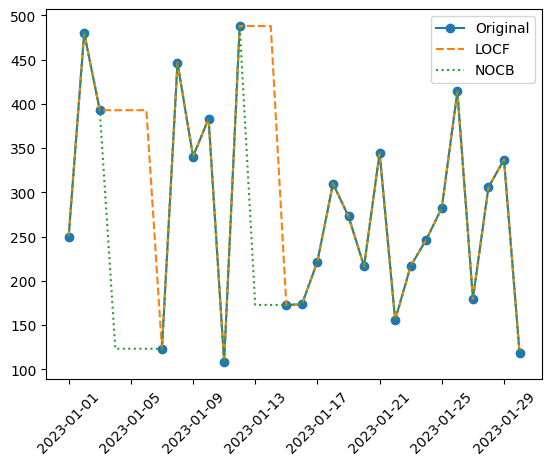

In [20]:
import matplotlib.pyplot as plt

plt.plot(df6['Fecha'], df6['Ventas'], label='Original', marker='o')
plt.plot(df6_locf['Fecha'], df6_locf['Ventas'], label='LOCF', linestyle='--')
plt.plot(df6_nocb['Fecha'], df6_nocb['Ventas'], label='NOCB', linestyle=':')

plt.legend()
plt.xticks(rotation=45)
plt.show()

###**Cuál método es más apropiado?**

* **LOCF** es más apropiado en este caso, ya que mantiene la lógica temporal de que los valores actuales dependen de los anteriores.
* **NOCB** utiliza información futura, lo cual puede no ser realista en contextos donde no se dispone de esos datos en el momento.

**Conclusión**

LOCF preserva mejor la coherencia temporal de la serie, mientras que NOCB puede introducir valores que no reflejan el comportamiento real en el tiempo.